In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('titanic.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df['Age']=df['Age'].fillna(df['Age'].median())
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [7]:
df.drop(columns=['Cabin'],inplace=True)

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [9]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [10]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

In [11]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,10,20,30,40,50,60],labels=['0-10','11-20','21-30','31-40','41-50','51-60'])

In [12]:
df['Embarked']=df['Embarked'].astype('category').cat.codes
df['AgeGroup']=df['AgeGroup'].cat.codes

In [13]:
df['FamilySize']=df['SibSp']+df['Parch']+1

In [14]:
features=['Pclass','Sex','Age','Fare','Embarked','FamilySize']
x=df[features]
y=df['Survived']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)
y_preds=rfc.predict(x_test)
print(accuracy_score(y_test,y_preds))

0.8044692737430168


In [16]:
# plot confusion matrix, feature importance

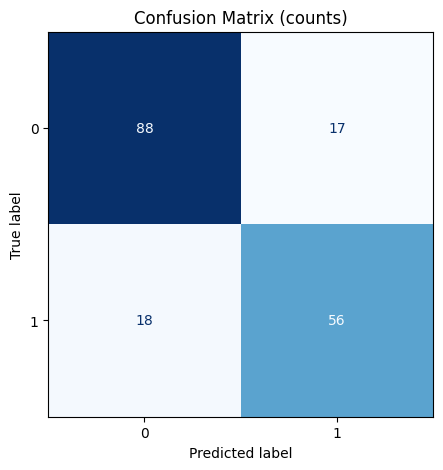

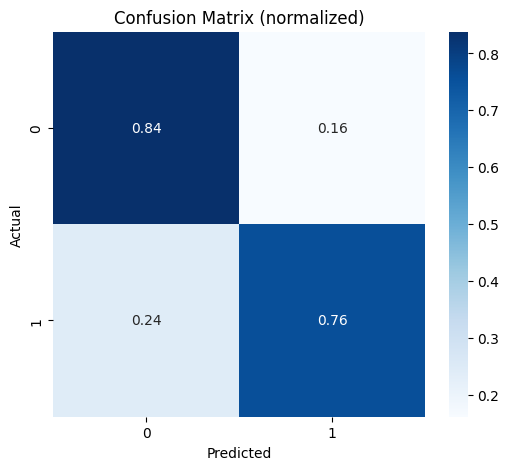

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       105
           1       0.77      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix (raw counts)
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix (counts)')
plt.show()

# Normalized confusion matrix (proportions)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=rfc.classes_, yticklabels=rfc.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (normalized)')
plt.show()

# Classification metrics
print(classification_report(y_test, y_preds, target_names=[str(c) for c in rfc.classes_]))

C:\Users\tonys\AppData\Local\Temp\ipykernel_9836\3850663660.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values, y=fi.index, palette='viridis')


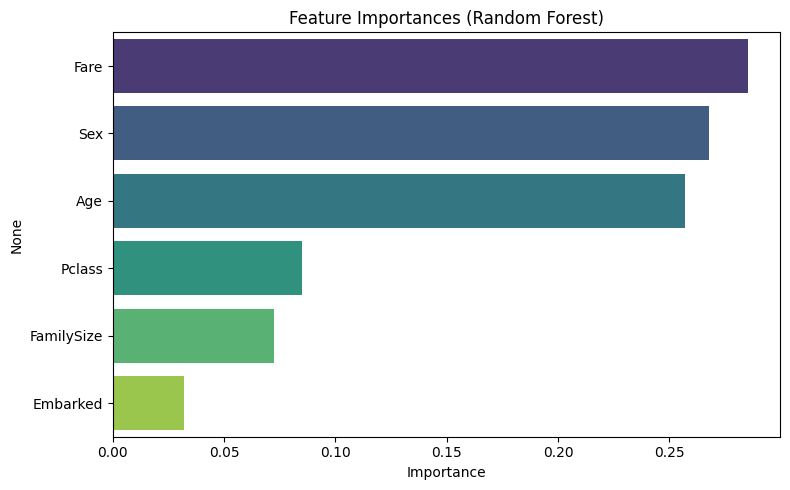

C:\Users\tonys\AppData\Local\Temp\ipykernel_9836\3850663660.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_series.values, y=perm_series.index, palette='magma')


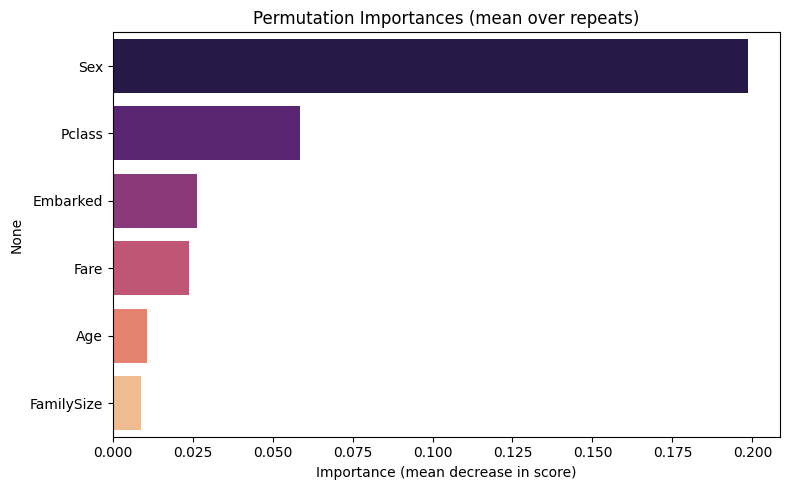

Built-in importances:
 Fare          0.285441
Sex           0.267999
Age           0.256950
Pclass        0.084893
FamilySize    0.072656
Embarked      0.032061
dtype: float64

Permutation importances (mean):
 Sex           0.198696
Pclass        0.058659
Embarked      0.026443
Fare          0.024022
Age           0.010615
FamilySize    0.008752
dtype: float64


In [18]:
# Built-in feature importances
import pandas as pd
fi = pd.Series(rfc.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=fi.values, y=fi.index, palette='viridis')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Optional: permutation importance (more reliable)
from sklearn.inspection import permutation_importance
perm = permutation_importance(rfc, x_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=perm_series.values, y=perm_series.index, palette='magma')
plt.title('Permutation Importances (mean over repeats)')
plt.xlabel('Importance (mean decrease in score)')
plt.tight_layout()
plt.show()

# Show numeric values
print("Built-in importances:\n", fi)
print("\nPermutation importances (mean):\n", perm_series)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)
y_preds=rfc.predict(x_test)
print(accuracy_score(y_test,y_preds))

0.8044692737430168
